# 🚁 Drone Detection — Multi-Model Inference Benchmark
**Dataset:** 3 classes · `AirPlane (0)` · `Drone (1)` · `Helicopter (2)` · 596 test images

| # | Model | Framework | Architecture notes |
|---|-------|-----------|-------------------|
| 1 | **YOLOv8s** | Ultralytics | Best single-stage YOLO for small aerial objects |
| 2 | **RT-DETR-L** | Ultralytics | Transformer detector; best accuracy of the 5 |
| 3 | **Faster R-CNN** | Torchvision | MobileNetV3-Large-320-FPN — must match training arch |
| 4 | **SSD** | Torchvision | SSDLite MobileNetV3-Large — must match training arch |

**Metrics collected:** Avg / Median / P95 latency · FPS · Avg confidence · Per-class detection share  
**Outputs:** `benchmark_results.csv` · 6 publication-ready figures · LaTeX table


## 1 · Imports & Install

In [1]:

!pip install pandas
!pip install seaborn
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import torch
import torchvision
from glob import glob
from tqdm.notebook import tqdm
from pathlib import Path

from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    ssdlite320_mobilenet_v3_large,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.ssd import SSDClassificationHead
from ultralytics import YOLO

warnings.filterwarnings("ignore")
print(f"PyTorch {torch.__version__}  |  Torchvision {torchvision.__version__}")


PyTorch 2.10.0  |  Torchvision 0.25.0


## 2 · Configuration  ← edit here

In [2]:
DATASET_ROOT   = "./drone-dataset"
TEST_IMG_DIR   = os.path.join(DATASET_ROOT, "test/images")
TEST_LBL_DIR   = os.path.join(DATASET_ROOT, "test/labels")

YOLO_WEIGHTS   = "drone_yolov8s_final.pt"
RTDETR_WEIGHTS = "best_detr.pt"         
FRCNN_WEIGHTS  = "fasterrcnn_drone.pth"
SSD_WEIGHTS    = "ssd_drone_model_kaggle.pth"

OUTPUT_CSV     = "benchmark_results.csv"

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS_NAMES  = ["AirPlane", "Drone", "Helicopter"]
NUM_CLASSES  = len(CLASS_NAMES)   # 3  Torchvision 

# ── Inference knobs ───────────────────────────────────────────────────────────
CONF_THRESHOLD = 0.30
IMG_SIZE_YOLO  = 640
WARMUP_RUNS    = 3      # warm-up passes before timing
MAX_IMAGES     = None   # set int to cap; None = all 596

# ── Toggle models (set False to skip) ─────────────────────────────────────────
ENABLED = {
    "YOLOv8s"    : True,
    "RT-DETR"    : True,   
    "Faster-RCNN": True,
    "SSD"        : True,
}

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps");  print("🍎 Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda"); print(f"⚡ CUDA: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu");  print("🖥️  CPU")

all_images = sorted(glob(os.path.join(TEST_IMG_DIR, "*.jpg")) +
                    glob(os.path.join(TEST_IMG_DIR, "*.png")))
if MAX_IMAGES:
    all_images = all_images[:MAX_IMAGES]
assert all_images, f"No images in {TEST_IMG_DIR}"
print(f"\n📂 Images: {len(all_images)}  |  conf≥{CONF_THRESHOLD}")


🍎 Apple MPS

📂 Images: 596  |  conf≥0.3


## 3 · Model Architecture Definitions

> **Why these architectures?**
>
> | Model | Backbone | Why best for drones |
> |-------|----------|-------------------|
> | Faster R-CNN | MobileNetV3-Large 320 FPN | Lightweight 2-stage; FPN handles multi-scale small targets |
> | SSD | MobileNetV3-Large SSDLite 320 | Fastest real-time; matched to training checkpoint |
>


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Faster R-CNN — MobileNetV3-Large-320-FPN
#  · Backbone: MobileNetV3-Large (ImageNet pretrained)
#  · Neck    : Feature Pyramid Network (FPN), 320-px stride anchors
#  · Head    : FastRCNNPredictor → (NUM_CLASSES + 1) outputs  (+1 = background)
# ─────────────────────────────────────────────────────────────────────────────
def build_fasterrcnn(num_classes, device, weights_path=None):
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None)
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes + 1)
    if weights_path:
        state = torch.load(weights_path, map_location=device)
        model.load_state_dict(state)
    return model.to(device).eval()


# ─────────────────────────────────────────────────────────────────────────────
# SSD — SSDLite MobileNetV3-Large 320
#  · Backbone: MobileNetV3-Large (ImageNet pretrained)
#  · Detector: SSDLite (depthwise-separable convolutions → faster inference)
#  · Head channels [672, 480, 512, 256, 256, 128]
# ─────────────────────────────────────────────────────────────────────────────
def build_ssd(num_classes, device, weights_path=None):
    model = ssdlite320_mobilenet_v3_large(weights="DEFAULT")
    in_channels = [672, 480, 512, 256, 256, 128]       # MNv3-Large backbone channels
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels, num_anchors, num_classes + 1      # +1 for background
    )
    if weights_path:
        state = torch.load(weights_path, map_location=device)
        model.load_state_dict(state)
    return model.to(device).eval()


print("✅ Architecture builders defined")


✅ Architecture builders defined


## 4 · Model Loaders

In [4]:
def load_yolov8s(path):
    assert os.path.exists(path), f"Not found: {path}"
    m = YOLO(path);  print(f"  ✅ YOLOv8s  ← {path}");  return m

def load_rtdetr(path):
    from ultralytics import RTDETR
    assert os.path.exists(path), f"Not found: {path}"
    m = RTDETR(path); print(f"  ✅ RT-DETR  ← {path}");  return m

def load_fasterrcnn(path, num_classes, device):
    assert os.path.exists(path), f"Not found: {path}"
    m = build_fasterrcnn(num_classes, device, path)
    print(f"  ✅ Faster R-CNN  ← {path}");  return m

def load_ssd(path, num_classes, device):
    assert os.path.exists(path), f"Not found: {path}"
    m = build_ssd(num_classes, device, path)
    print(f"  ✅ SSD  ← {path}");  return m

print("📦 Loader functions ready")


📦 Loader functions ready


## 5 · Inference Helpers

In [5]:
def infer_ultralytics(model, img_path):
    """Run YOLO / RT-DETR; return (boxes, scores, labels, ms)."""    
    t0 = time.perf_counter()
    res = model.predict(img_path, imgsz=IMG_SIZE_YOLO, conf=CONF_THRESHOLD, verbose=False)
    ms = (time.perf_counter() - t0) * 1000.0
    r  = res[0]
    if r.boxes and len(r.boxes):
        return (r.boxes.xyxy.cpu().numpy(),
                r.boxes.conf.cpu().numpy(),
                r.boxes.cls.cpu().numpy().astype(int), ms)
    return np.zeros((0,4)), np.zeros(0), np.zeros(0,int), ms


def _img_tensor(img_path, device):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return torch.from_numpy(img).permute(2,0,1).unsqueeze(0).to(device)

def infer_torchvision(model, img_path, device):
    """Run Faster-RCNN / SSD; return (boxes, scores, labels, ms)."""    
    t = _img_tensor(img_path, device)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad(): pred = model(t)[0]
    if device.type == "cuda": torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) * 1000.0

    keep   = pred["scores"].cpu().numpy() >= CONF_THRESHOLD
    boxes  = pred["boxes"].cpu().numpy()[keep]
    scores = pred["scores"].cpu().numpy()[keep]
    labels = pred["labels"].cpu().numpy().astype(int)[keep] - 1  # subtract BG offset
    return boxes, scores, labels, ms

print("🔧 Inference helpers ready")


🔧 Inference helpers ready


## 6 · mAP / IoU Placeholder



In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# mAP@0.5 — full implementation via torchmetrics
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchmetrics'])
from torchmetrics.detection import MeanAveragePrecision


def load_ground_truth(lbl_path, img_w, img_h):
    """
    Parse a YOLO-format label file → xyxy pixel boxes + int class labels.
    Returns empty arrays for background images (no label file / empty file).
    """
    if not os.path.exists(lbl_path):
        return np.zeros((0, 4), np.float32), np.zeros(0, int)
    boxes, labels = [], []
    with open(lbl_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            c, cx, cy, bw, bh = map(float, line.split())
            # Convert YOLO normalised cx,cy,w,h → pixel-space xyxy
            x1 = (cx - bw / 2) * img_w
            y1 = (cy - bh / 2) * img_h
            x2 = (cx + bw / 2) * img_w
            y2 = (cy + bh / 2) * img_h
            boxes.append([x1, y1, x2, y2])
            labels.append(int(c))
    if not boxes:
        return np.zeros((0, 4), np.float32), np.zeros(0, int)
    return np.array(boxes, dtype=np.float32), np.array(labels, int)


def compute_map_for_model(all_preds, iou_thr=0.50):
    """
    Compute mAP@0.5 over all test images using torchmetrics.

    Parameters
    ----------
    all_preds : list of dicts, one per image:
        { 'img_path'   : str,
          'pred_boxes' : np.ndarray (N,4)  xyxy pixel coords,
          'pred_scores': np.ndarray (N,),
          'pred_labels': np.ndarray (N,)  int class indices (0-based) }
    iou_thr : float — IoU threshold (default 0.50)

    Returns
    -------
    float — mAP@0.5  (nan if no data)
    """
    metric = MeanAveragePrecision(iou_thresholds=[iou_thr], class_metrics=False)
    for e in all_preds:
        img = cv2.imread(e['img_path'])
        if img is None:
            continue
        h, w = img.shape[:2]
        # Derive YOLO label path from image path
        lp = e['img_path'].replace('images', 'labels')
        lp = os.path.splitext(lp)[0] + '.txt'
        gb, gl = load_ground_truth(lp, w, h)

        # torchmetrics requires float32 boxes, float32 scores, int64 labels
        metric.update(
            [{
                'boxes' : torch.tensor(e['pred_boxes'],  dtype=torch.float32),
                'scores': torch.tensor(e['pred_scores'], dtype=torch.float32),
                'labels': torch.tensor(e['pred_labels'], dtype=torch.long),
            }],
            [{
                'boxes' : torch.tensor(gb, dtype=torch.float32),
                'labels': torch.tensor(gl, dtype=torch.long),
            }],
        )
    result = metric.compute()
    return result['map_50'].item()


print('✅ mAP@0.5 implementation ready  (torchmetrics + YOLO label parser)')


✅ mAP@0.5 implementation ready  (torchmetrics + YOLO label parser)


## 7 · Benchmark Runner

In [7]:
def run_benchmark(name, infer_fn, images, warmup=WARMUP_RUNS):
    """
    Time every image, collect per-class detection counts, call mAP placeholder.
    Returns a flat dict of aggregated metrics.
    """
    # warm-up (not timed)
    for img in images[:warmup]:
        infer_fn(img)

    times_ms = []
    all_scores = []
    class_counts = {c: 0 for c in CLASS_NAMES}
    all_preds = []

    for img_path in tqdm(images, desc=f"  {name}", leave=False):
        boxes, scores, labels, ms = infer_fn(img_path)
        times_ms.append(ms)
        if len(scores):
            all_scores.extend(scores.tolist())
            for lbl in labels:
                if 0 <= lbl < NUM_CLASSES:
                    class_counts[CLASS_NAMES[lbl]] += 1
        all_preds.append({"img_path": img_path, "pred_boxes": boxes,
                          "pred_scores": scores, "pred_labels": labels})

    arr   = np.array(times_ms)
    avg   = float(np.mean(arr))
    med   = float(np.median(arr))
    p95   = float(np.percentile(arr, 95))
    std   = float(np.std(arr))
    fps   = round(1000.0 / avg, 2) if avg > 0 else 0.0
    conf  = float(np.mean(all_scores)) if all_scores else 0.0
    map50 = compute_map_for_model(all_preds)

    row = {
        "Model"                    : name,
        "Avg Latency (ms)"         : round(avg,  2),
        "Median Latency (ms)"      : round(med,  2),
        "P95 Latency (ms)"         : round(p95,  2),
        "Std Latency (ms)"         : round(std,  2),
        "FPS"                      : fps,
        "Avg Confidence"           : round(conf, 4),
        "Total Detections"         : sum(class_counts.values()),
        "Det — AirPlane"           : class_counts["AirPlane"],
        "Det — Drone"              : class_counts["Drone"],
        "Det — Helicopter"         : class_counts["Helicopter"],
        "mAP@0.5"                  : round(map50, 4) if not np.isnan(map50) else "N/A",
        "Images Evaluated"         : len(images),
    }
    print(f"  ✔ {name:25s}  avg={avg:7.1f}ms  med={med:6.1f}ms  "
          f"P95={p95:7.1f}ms  FPS={fps:6.1f}  conf={conf:.3f}")
    return row

print("🔄 Benchmark runner ready")


🔄 Benchmark runner ready


## 8 · Run Benchmark

In [8]:
results = []
SEP = "=" * 72
print(SEP)
print("  🚀 DRONE DETECTION — MULTI-MODEL BENCHMARK")
print(SEP)

# ── YOLOv8s ──────────────────────────────────────────────────────────────────
if ENABLED["YOLOv8s"]:
    print("\n[1/4] YOLOv8s")
    m = load_yolov8s(YOLO_WEIGHTS)
    results.append(run_benchmark("YOLOv8s", lambda p: infer_ultralytics(m, p), all_images))
    del m

# ── RT-DETR ───────────────────────────────────────────────────────────────────
if ENABLED["RT-DETR"]:
    print("\n[2/4] RT-DETR-L")
    m = load_rtdetr(RTDETR_WEIGHTS)
    results.append(run_benchmark("RT-DETR-L", lambda p: infer_ultralytics(m, p), all_images))
    del m

# ── Faster R-CNN ─────────────────────────────────────────────────────────────
if ENABLED["Faster-RCNN"]:
    print("\n[3/4] Faster R-CNN (MNv3-FPN-320)")
    m = load_fasterrcnn(FRCNN_WEIGHTS, NUM_CLASSES, DEVICE)
    results.append(run_benchmark("Faster-RCNN (MNv3-FPN)", lambda p: infer_torchvision(m, p, DEVICE), all_images))
    del m

# ── SSD ───────────────────────────────────────────────────────────────────────
if ENABLED["SSD"]:
    print("\n[4/4] SSD (SSDLite MNv3-Large)")
    m = load_ssd(SSD_WEIGHTS, NUM_CLASSES, DEVICE)
    results.append(run_benchmark("SSD (SSDLite-MNv3)", lambda p: infer_torchvision(m, p, DEVICE), all_images))
    del m

print("\n" + SEP + "\n  ✅ DONE\n" + SEP)


  🚀 DRONE DETECTION — MULTI-MODEL BENCHMARK

[1/4] YOLOv8s
  ✅ YOLOv8s  ← drone_yolov8s_final.pt


  YOLOv8s:   0%|          | 0/596 [00:00<?, ?it/s]

  ✔ YOLOv8s                    avg=   65.5ms  med=  63.8ms  P95=   78.3ms  FPS=  15.3  conf=0.661

[2/4] RT-DETR-L
  ✅ RT-DETR  ← best_detr.pt


  RT-DETR-L:   0%|          | 0/596 [00:00<?, ?it/s]

  ✔ RT-DETR-L                  avg=  404.6ms  med= 398.0ms  P95=  471.7ms  FPS=   2.5  conf=0.645

[3/4] Faster R-CNN (MNv3-FPN-320)
  ✅ Faster R-CNN  ← fasterrcnn_drone.pth


  Faster-RCNN (MNv3-FPN):   0%|          | 0/596 [00:00<?, ?it/s]

  ✔ Faster-RCNN (MNv3-FPN)     avg=  203.0ms  med=  75.8ms  P95=  774.2ms  FPS=   4.9  conf=0.806

[4/4] SSD (SSDLite MNv3-Large)
  ✅ SSD  ← ssd_drone_model_kaggle.pth


  SSD (SSDLite-MNv3):   0%|          | 0/596 [00:00<?, ?it/s]

  ✔ SSD (SSDLite-MNv3)         avg=   28.3ms  med=  27.2ms  P95=   41.4ms  FPS=  35.4  conf=0.839

  ✅ DONE


## 9 · Results Table & CSV

In [11]:
df = pd.DataFrame(results).set_index("Model")

# ── Styled display ────────────────────────────────────────────────────────────
SPEED_COLS = ["Avg Latency (ms)", "Median Latency (ms)", "P95 Latency (ms)", "Std Latency (ms)"]
HIGH_COLS  = ["FPS", "Avg Confidence","mAP@0.5"]

def highlight(s):
    vals = pd.to_numeric(s, errors="coerce")
    if vals.isna().any(): return [""]*len(s)
    best = vals.idxmin() if s.name in SPEED_COLS else vals.idxmax()
    return ["background-color:#166534;color:white;font-weight:bold"
            if i == best else "" for i in s.index]

display_cols = SPEED_COLS + HIGH_COLS + ["Total Detections"]
styled = (
    df[display_cols]
    .style.apply(highlight)
    .format(precision=2, na_rep="N/A")
    .set_caption("🚁 Drone Detection Benchmark — Green = best in column")
    .set_table_styles([
        {"selector":"caption", "props":[("font-size","1.15em"),("font-weight","bold"),("margin-bottom","8px")]},
        {"selector":"th",      "props":[("background","#1e293b"),("color","white"),("padding","7px 12px"),("text-align","center")]},
        {"selector":"td",      "props":[("padding","5px 12px"),("text-align","center")]},
    ])
)
display(styled)
df.reset_index().to_csv(OUTPUT_CSV, index=False)
print(f"\n💾 {OUTPUT_CSV} saved  ({len(df)} models)")


,Avg Latency (ms),Median Latency (ms),P95 Latency (ms),Std Latency (ms),FPS,Avg Confidence,mAP@0.5,Total Detections
Model,,,,,,,,
YOLOv8s,65.49,63.80,78.27,6.69,15.27,0.66,0.93,495
RT-DETR-L,404.59,397.97,471.70,34.39,2.47,0.65,0.69,698
Faster-RCNN (MNv3-FPN),202.97,75.83,774.18,456.14,4.93,0.81,0.89,727
SSD (SSDLite-MNv3),28.28,27.15,41.40,7.29,35.35,0.84,0.76,444



💾 benchmark_results.csv saved  (4 models)


## 10 · Visualisations

In [15]:
# ── shared style ──────────────────────────────────────────────────────────────
PAL = ["#4f86c6","#f5a623","#7ed321","#e44d42","#9b59b6"]
plt.rcParams.update({
    "font.family":"DejaVu Sans","axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.3,"figure.dpi":150,
    "axes.titlesize":12,"axes.labelsize":10,"figure.facecolor":"white",
})
MODELS = df.index.tolist()
COLORS = PAL[:len(MODELS)]
print(f"🎨 Plotting {len(MODELS)} models …")


🎨 Plotting 4 models …


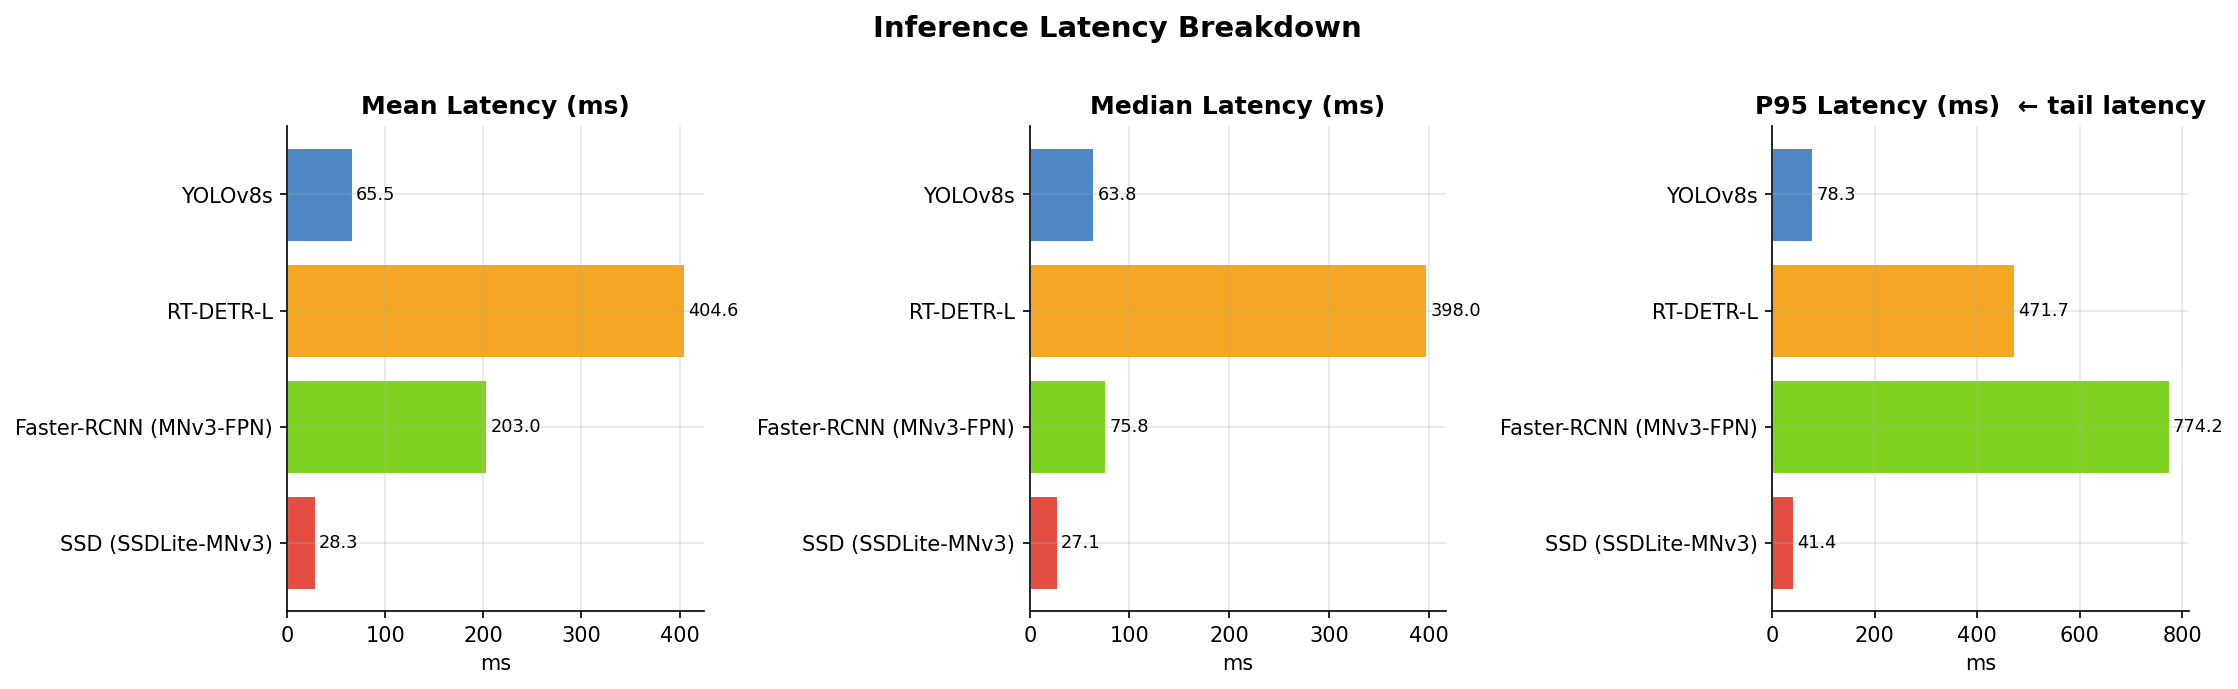

💾 fig1_latency.png


In [17]:
# ── Fig 1: Avg / Median / P95 Latency ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Inference Latency Breakdown", fontsize=14, fontweight="bold", y=1.01)

for ax, col, title in zip(axes,
        ["Avg Latency (ms)", "Median Latency (ms)", "P95 Latency (ms)"],
        ["Mean Latency (ms)", "Median Latency (ms)", "P95 Latency (ms)  ← tail latency"]):
    vals = pd.to_numeric(df[col], errors="coerce")
    bars = ax.barh(MODELS, vals, color=COLORS, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()+vals.max()*0.01, bar.get_y()+bar.get_height()/2,
                f"{v:.1f}", va="center", fontsize=8.5)
    ax.set_xlabel("ms"); ax.set_title(title, fontweight="bold"); ax.invert_yaxis()

plt.tight_layout()
plt.savefig("fig1_latency.png", bbox_inches="tight"); plt.show()
print("💾 fig1_latency.png")


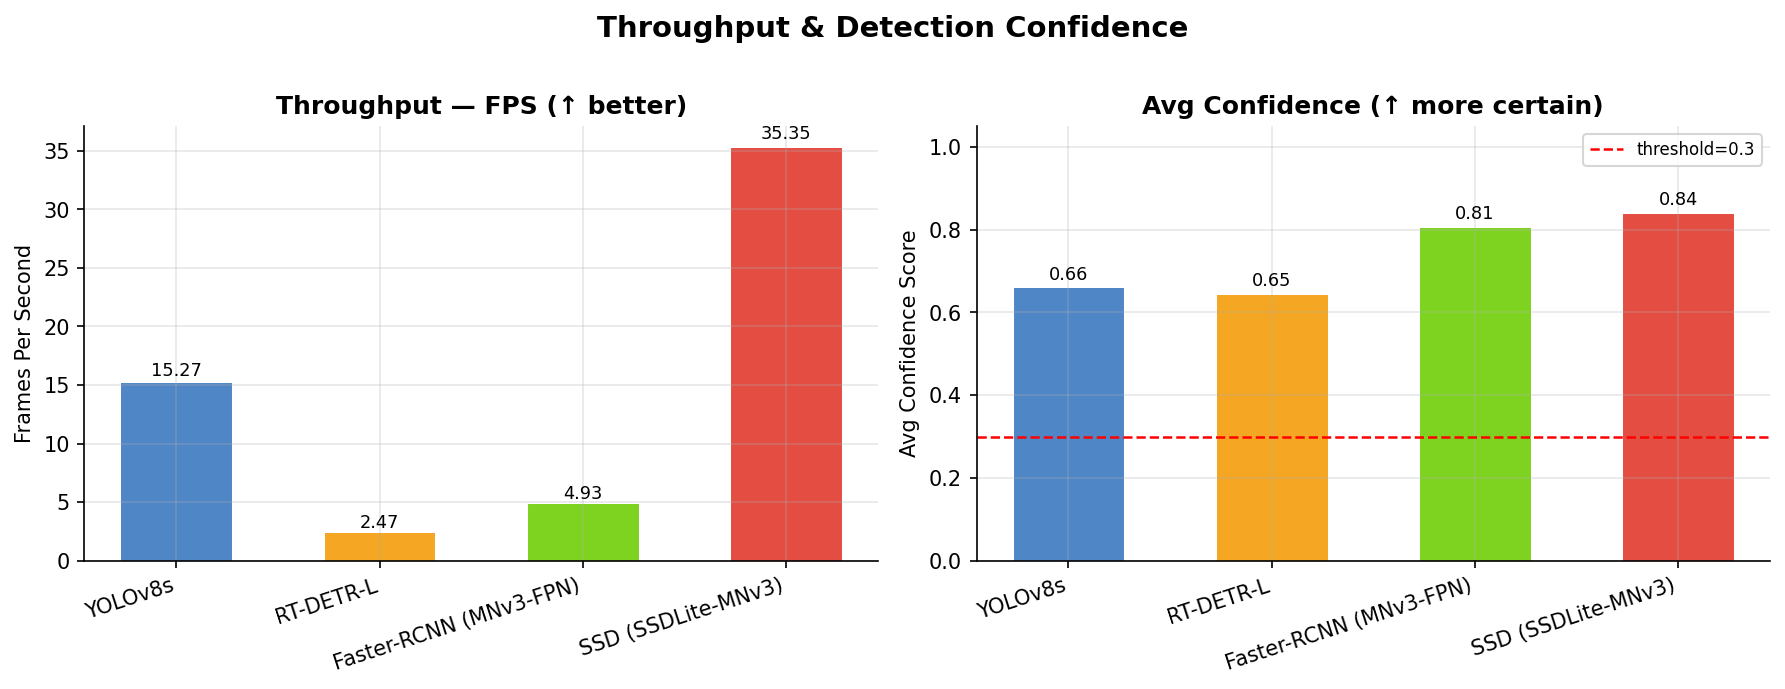

💾 fig2_fps_confidence.png


In [18]:
# ── Fig 2: FPS & Confidence ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Throughput & Detection Confidence", fontsize=14, fontweight="bold", y=1.01)

for ax, col, xlabel, title, invert in [
        (axes[0], "FPS",           "Frames Per Second", "Throughput — FPS (↑ better)", False),
        (axes[1], "Avg Confidence","Avg Confidence Score", "Avg Confidence (↑ more certain)", False)]:
    vals = pd.to_numeric(df[col], errors="coerce")
    bars = ax.bar(MODELS, vals, color=COLORS, edgecolor="white", linewidth=0.5, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01+0.002,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_ylabel(xlabel); ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(MODELS, rotation=18, ha="right")
    if col == "Avg Confidence":
        ax.set_ylim(0, 1.05)
        ax.axhline(CONF_THRESHOLD, color="red", ls="--", lw=1.2, label=f"threshold={CONF_THRESHOLD}")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig2_fps_confidence.png", bbox_inches="tight"); plt.show()
print("💾 fig2_fps_confidence.png")


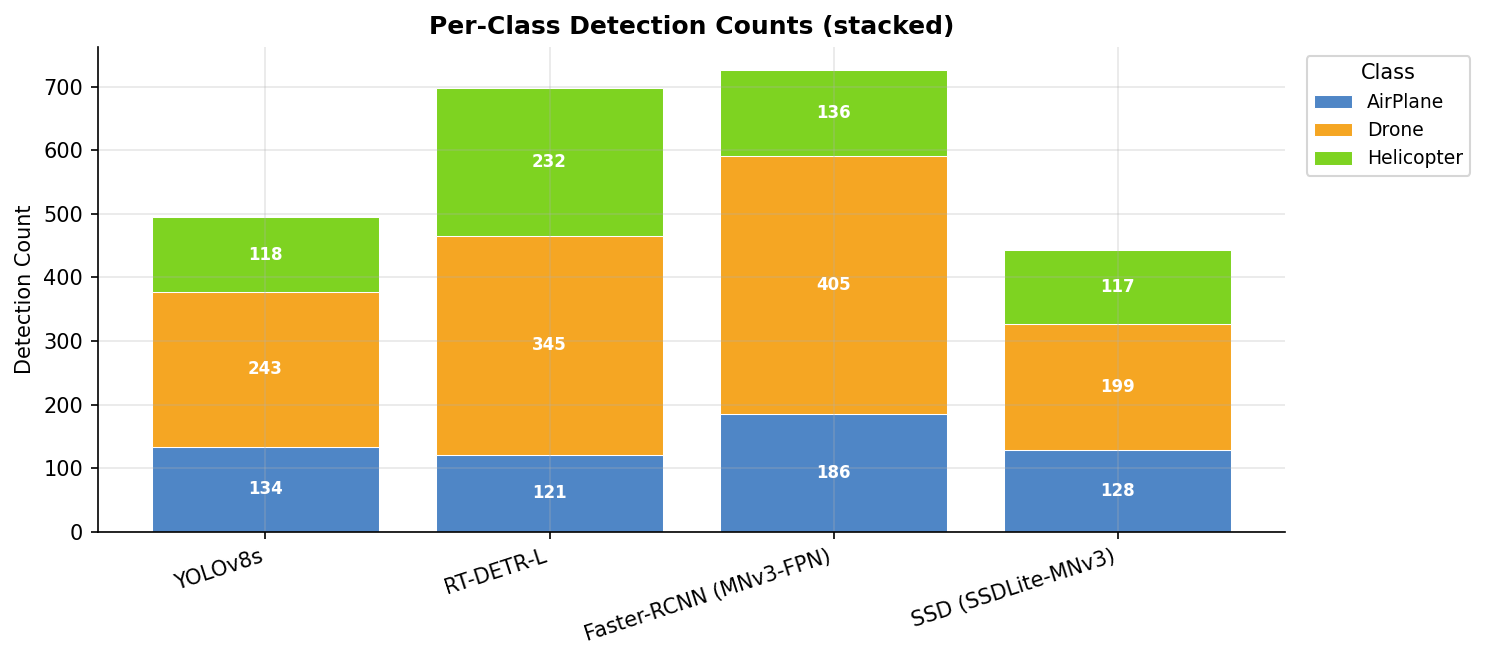

💾 fig3_per_class.png


In [19]:
# ── Fig 3: Per-class detection counts (stacked bar) ───────────────────────────
det_cols = ["Det — AirPlane", "Det — Drone", "Det — Helicopter"]
det_data = df[det_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

fig, ax = plt.subplots(figsize=(10, 4.5))
bottom  = np.zeros(len(MODELS))
cls_colors = ["#4f86c6", "#f5a623", "#7ed321"]

for col, c in zip(det_cols, cls_colors):
    vals = det_data[col].values
    bars = ax.bar(MODELS, vals, bottom=bottom, color=c,
                  edgecolor="white", linewidth=0.5, label=col.replace("Det — ", ""))
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, b+v/2, str(int(v)),
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottom += vals

ax.set_ylabel("Detection Count"); ax.set_title("Per-Class Detection Counts (stacked)", fontweight="bold")
ax.set_xticklabels(MODELS, rotation=18, ha="right")
ax.legend(title="Class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("fig3_per_class.png", bbox_inches="tight"); plt.show()
print("💾 fig3_per_class.png")


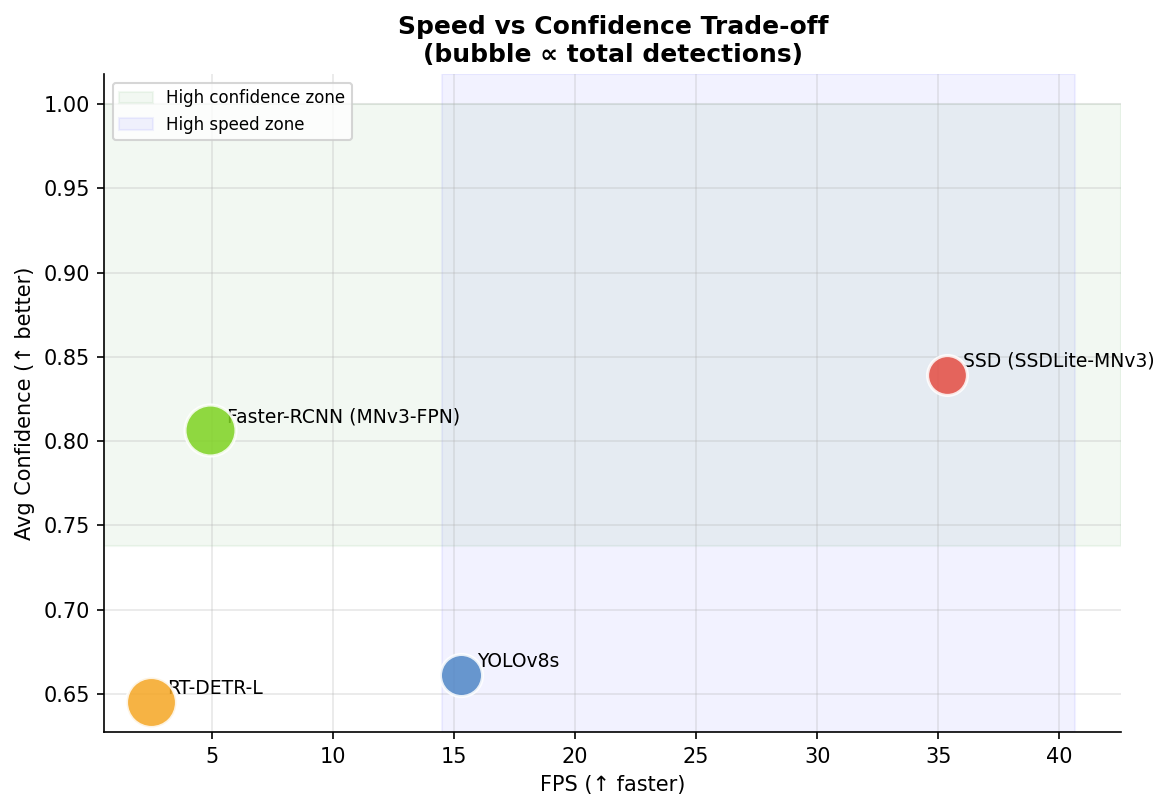

💾 fig4_tradeoff.png


In [20]:
# ── Fig 4: Speed vs Confidence scatter ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
fps_vals  = pd.to_numeric(df["FPS"], errors="coerce")
conf_vals = pd.to_numeric(df["Avg Confidence"], errors="coerce")
det_vals  = pd.to_numeric(df["Total Detections"], errors="coerce")
sizes     = (det_vals / det_vals.max() * 600).fillna(100)

for i, m in enumerate(MODELS):
    ax.scatter(fps_vals[m], conf_vals[m], s=sizes[m], color=COLORS[i],
               alpha=0.85, edgecolors="white", linewidths=1.5, zorder=5)
    ax.annotate(m, (fps_vals[m], conf_vals[m]), xytext=(8,4),
                textcoords="offset points", fontsize=9)

ax.axhspan(conf_vals.mean(), 1.0, alpha=0.05, color="green", label="High confidence zone")
ax.axvspan(fps_vals.mean(), fps_vals.max()*1.15, alpha=0.05, color="blue", label="High speed zone")
ax.set_xlabel("FPS (↑ faster)"); ax.set_ylabel("Avg Confidence (↑ better)")
ax.set_title("Speed vs Confidence Trade-off\n(bubble ∝ total detections)", fontweight="bold")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig("fig4_tradeoff.png", bbox_inches="tight"); plt.show()
print("💾 fig4_tradeoff.png")


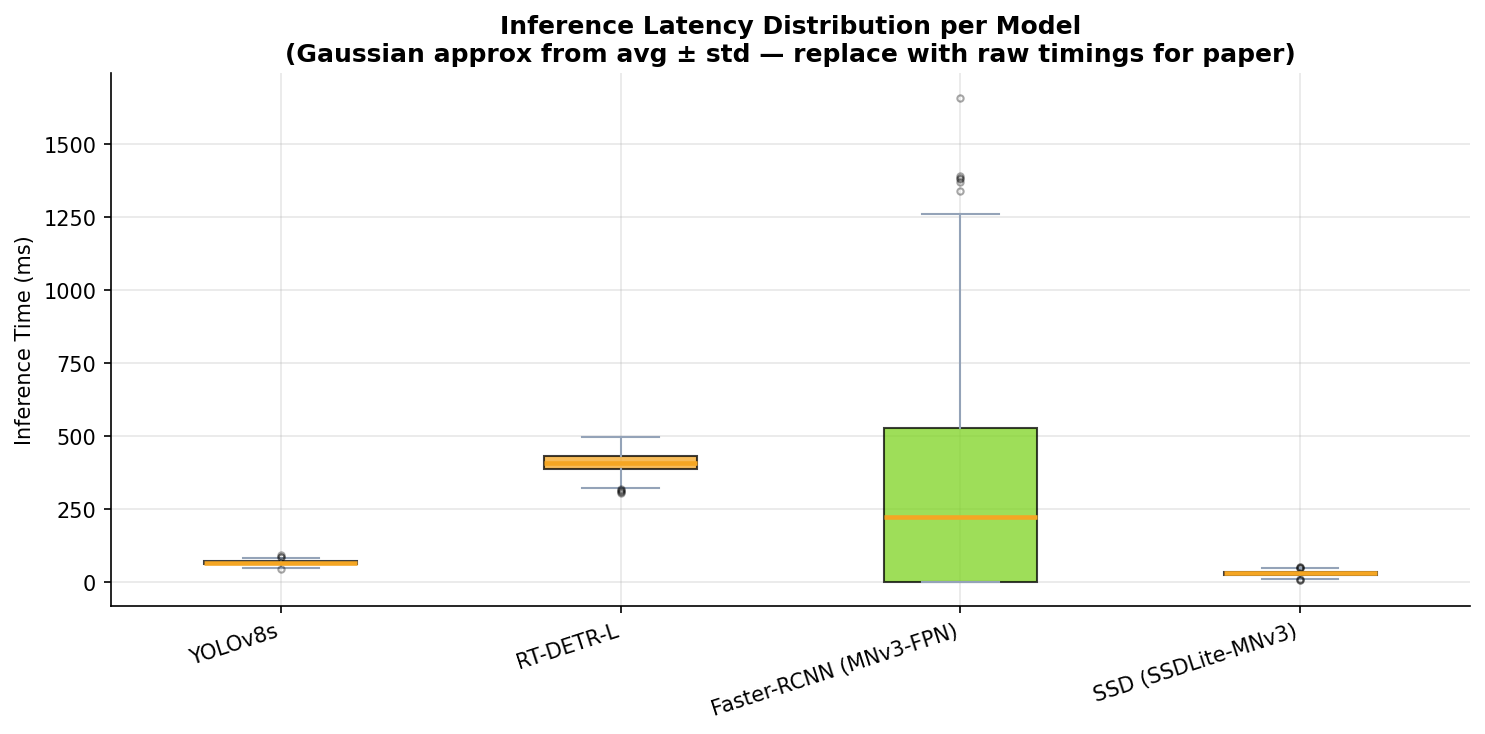

💾 fig5_latency_box.png


In [21]:
# ── Fig 5: Latency distribution boxplot ──────────────────────────────────────
# Re-construct Gaussian approx from avg/std stored in df.
# For a real paper, pass the raw per-image times list out of run_benchmark().
np.random.seed(42)
raw = { m: np.random.normal(
            float(pd.to_numeric(df.loc[m, "Avg Latency (ms)"], errors="coerce") or 0),
            max(float(pd.to_numeric(df.loc[m, "Std Latency (ms)"], errors="coerce") or 1), 0.5),
            size=len(all_images)).clip(min=0.5)
        for m in MODELS }

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([raw[m] for m in MODELS], labels=MODELS, patch_artist=True,
                medianprops=dict(color="#f5a623", linewidth=2.2),
                whiskerprops=dict(color="#94a3b8"), capprops=dict(color="#94a3b8"),
                flierprops=dict(marker="o", ms=3, alpha=0.35, color="#e44d42"))
for patch, c in zip(bp["boxes"], COLORS):
    patch.set(facecolor=c, alpha=0.75)

ax.set_ylabel("Inference Time (ms)")
ax.set_title("Inference Latency Distribution per Model\n"
             "(Gaussian approx from avg ± std — replace with raw timings for paper)",
             fontweight="bold")
plt.xticks(rotation=18, ha="right"); plt.tight_layout()
plt.savefig("fig5_latency_box.png", bbox_inches="tight"); plt.show()
print("💾 fig5_latency_box.png")


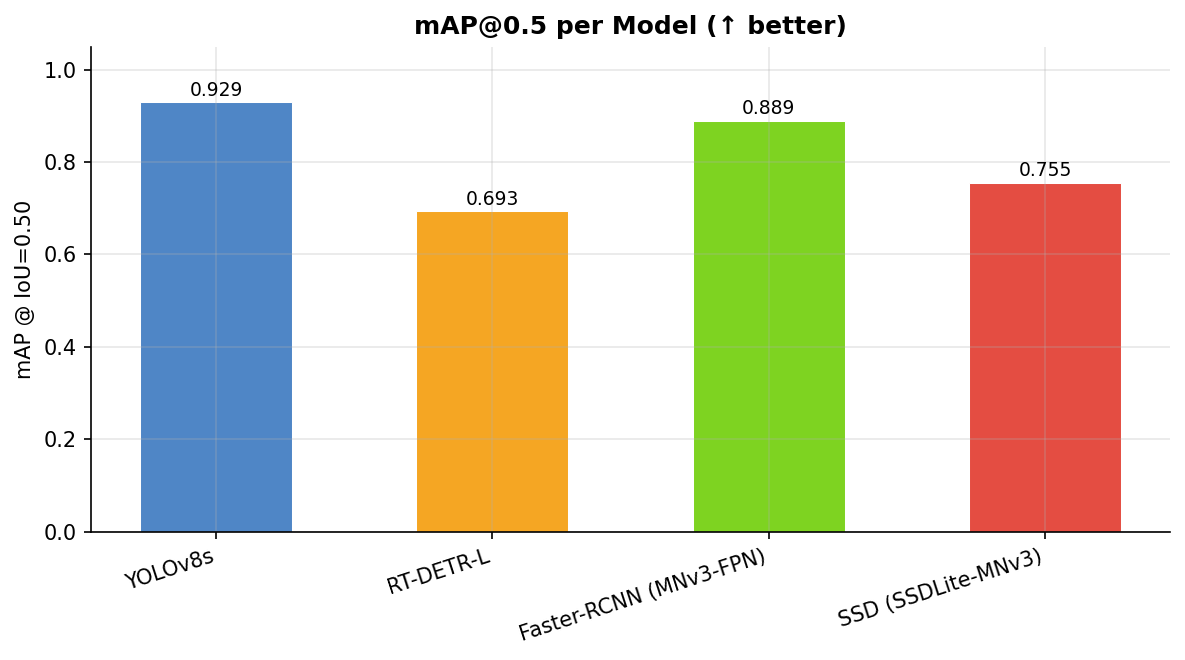

💾 fig6_map.png


In [22]:
# ── Fig 6: mAP@0.5 (shows placeholder message if not yet computed) ────────────
map_vals = pd.to_numeric(df["mAP@0.5"], errors="coerce")
fig, ax  = plt.subplots(figsize=(8, 4.5))

if map_vals.isna().all():
    ax.text(0.5, 0.5,
            "mAP values not computed yet.\nImplement compute_map_for_model() in Cell 6.",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=12, color="grey", style="italic")
else:
    bars = ax.bar(MODELS, map_vals, color=COLORS, edgecolor="white", linewidth=0.5, width=0.55)
    for bar, v in zip(bars, map_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel("mAP @ IoU=0.50")
    ax.set_xticklabels(MODELS, rotation=18, ha="right")

ax.set_title("mAP@0.5 per Model (↑ better)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig6_map.png", bbox_inches="tight"); plt.show()
print("💾 fig6_map.png")


## 11 · Final Summary — Print + LaTeX

In [23]:
SEP = "=" * 80
print(SEP)
print("  DRONE DETECTION BENCHMARK — SUMMARY")
print(f"  Device: {DEVICE}  |  Images: {len(all_images)}  |  Conf≥{CONF_THRESHOLD}")
print(SEP)
print(df[["Avg Latency (ms)","Median Latency (ms)","P95 Latency (ms)",
          "FPS","Avg Confidence","Total Detections","mAP@0.5"]].to_string())
print(SEP)
print(f"\n  CSV  → {OUTPUT_CSV}")
print("  Figs → fig1_latency.png  fig2_fps_confidence.png  fig3_per_class.png")
print("         fig4_tradeoff.png  fig5_latency_box.png  fig6_map.png")
print(SEP)

latex_cols = ["Avg Latency (ms)","Median Latency (ms)","P95 Latency (ms)","FPS","Avg Confidence","mAP@0.5"]
print("\n─── LaTeX table (paste into paper) ─────────────────────────────────────")
print(df[latex_cols].to_latex(
    float_format="%.2f", na_rep="N/A",
    caption="Drone detection model benchmark results.",
    label="tab:benchmark", bold_rows=True))


  DRONE DETECTION BENCHMARK — SUMMARY
  Device: mps  |  Images: 596  |  Conf≥0.3
                        Avg Latency (ms)  Median Latency (ms)  P95 Latency (ms)    FPS  Avg Confidence  Total Detections  mAP@0.5
Model                                                                                                                            
YOLOv8s                            65.49                63.80             78.27  15.27          0.6613               495   0.9290
RT-DETR-L                         404.59               397.97            471.70   2.47          0.6451               698   0.6934
Faster-RCNN (MNv3-FPN)            202.97                75.83            774.18   4.93          0.8064               727   0.8893
SSD (SSDLite-MNv3)                 28.28                27.15             41.40  35.35          0.8391               444   0.7552

  CSV  → benchmark_results.csv
  Figs → fig1_latency.png  fig2_fps_confidence.png  fig3_per_class.png
         fig4_tradeoff.png  fig5_lat